In [101]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from tensorflow import keras
from tensorflow.keras import layers

from scipy.stats import chi2_contingency

# magic word for producing visualizations in notebook
%matplotlib inline

base_path = "data/"
data1_path = base_path + "ST000368_1.txt"
data2_path = base_path + "ST000369.txt"

In [15]:
# function to convert file to pandas dataframe
def process_data(data_path, metabolite_offset):
    with open(data_path) as f:
        lines = f.read().split("\n")

    ## the first line is patient IDs
    keys = lines[0].split("\t")
    # print(len(keys))

    ## the second line is clinical data for each patient ID (organ/cancer/smoker/gender)
    clinical_data = [x.split(" | ") for x in lines[1].split("\t")]
    clinical_data = [([y.split(":")[len(y.split(":")) - 1] for y in x]) for x in clinical_data]
    # print(len(clinical_data))

    result = dict(zip(keys, clinical_data))
    
    ## the remaining lines are metabolomics
    ## error, some lines are NA. figure out where NA should be removed when attaching metabolomics
    for n in range(2, len(lines)):
        split_metabolics = lines[n].split("\t")
        zipped = list(zip(keys, split_metabolics))
        for x in zipped:
            result[x[0]].append(x[1])

    ## remove these rows as they are column names/identifiers for metabolites and not informative 
    metabolites = result.pop("Metabolite_name")
    refmet_name = result.pop("RefMet_name")
    keys.remove("Metabolite_name")
    keys.remove("RefMet_name")

    ## create column names and generate a dataframe to return
    colnames = ["organ", "cancer_status", "smoker", "gender"]
    for x in metabolites[1:-1]:
        colnames.append(x)
        
    df = pd.DataFrame(result).T
    df.columns = colnames

    return df

df1 = process_data(data1_path, 2)
df2 = process_data(data2_path, 2)
combined_df = pd.concat([df1, df2])[(list(set(df1.columns) & set(df2.columns)))]

# combined_df.to_csv(base_path + "metabolites.csv")

In [16]:
data = combined_df.copy()
data = data[data["gender"] != "NA"]

y = (data["cancer_status"] == "Healthy").map({False: 1, True: 0})
X_clinical = data.drop(["organ"], axis=1)

X_clinical["smoker"] = X_clinical["smoker"].map({"Former": 0, "Current": 1})
X_clinical["gender"] = X_clinical["gender"].map({"F": 0, "M": 1})
X_clinical["cancer_status"] = (X_clinical["cancer_status"] == "Healthy").map({False: 1, True: 0})

X_metabolics = data.drop("cancer_status", axis=1).drop(["smoker", "gender", "organ"], axis=1)

def na_vals(X):
    X = X.replace("", np.nan)
    X = X.apply(pd.to_numeric)
    X = X.fillna(X.mean(numeric_only=True))
    return X

X_clinical = na_vals(X_clinical)
X_metabolics = na_vals(X_metabolics)
combined_df = X_clinical

### Evaluation showin the gender , smoking and cancer relationship 

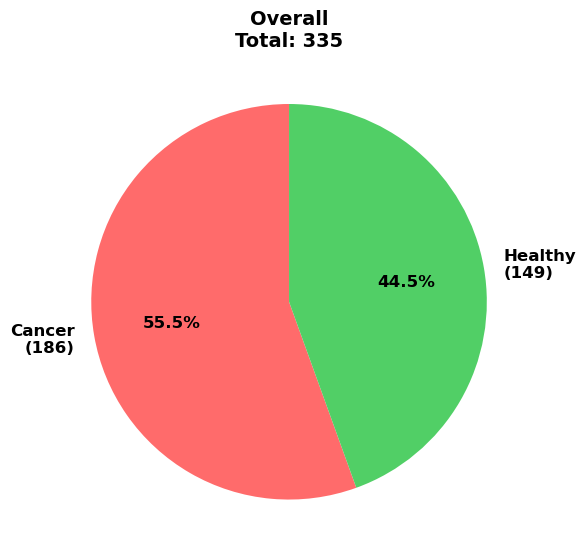

In [18]:
# Calculate counts
cancer = ((combined_df['cancer_status'] == 1)).sum()
healthy = ((combined_df['cancer_status'] == 0)).sum()

# Create figure with 3 pie charts
fig, axes = plt.subplots(1, 1, figsize=(6, 8))
overall_data = [cancer, healthy]
overall_labels = [f'Cancer\n({cancer})', f'Healthy\n({healthy})']
colors3 = ['#ff6b6b', '#51cf66']

axes.pie(overall_data, labels=overall_labels, autopct='%1.1f%%',
            colors=colors3, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes.set_title('Overall\n' + f'Total: {len(combined_df)}', 
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + 'demography_cancer_smokers_gen.png', dpi=300, bbox_inches='tight')

plt.show()

### Feature  Scaling

In [99]:
X_all = combined_df.drop('cancer_status', axis=1)
y_all = combined_df['cancer_status']

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler = StandardScaler()
s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

num_components = 25
pca = PCA(num_components)
pca_train = pca.fit_transform(s_train)
pca_test = pca.transform(s_test)
pca_train.shape


pca_log = LogisticRegression()
normal_log = LogisticRegression()

pca_log.fit(pca_train, y_train)
normal_log.fit(s_train, y_train)

y_pred = pca_log.predict(pca_test)
acc = accuracy_score(y_test, y_pred)
print("PCA LOGREGRESSION ACC:", acc)

y_pred = normal_log.predict(s_test)
acc = accuracy_score(y_test, y_pred)
print("NORMAL LOGREGRESSION ACC:", acc)


PCA LOGREGRESSION ACC: 0.6119402985074627
NORMAL LOGREGRESSION ACC: 0.6417910447761194


### Clustering based on PCA Components 

In [ ]:
#when using all components
#X_features = pca_df.drop('cancer_status', axis=1)
# If you know the column names
X_features = pca_df[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]

In [ ]:

X_features = pca_
print(f"Features shape: {X_features.shape}")
print(f"Number of samples: {len(X_features)}")
print(f"Number of PCA features: {X_features.shape[1]}")


# Step 2: Find optimal number of clusters using Elbow Method and Silhouette Score
print("\n" + "="*70)
print("Finding optimal number of clusters...")
print("="*70)

scores = []
silhouette_scores = []
centers = list(range(2, 15))  # Start from 2 (can't compute silhouette for 1 cluster)

for center in centers:
    # Fit KMeans
    kmeans = KMeans(n_clusters=center, random_state=42, n_init=10, max_iter=30)
    labels = kmeans.fit_predict(X_features)
    
    # Get inertia score (within-cluster sum of squares)
    score = kmeans.inertia_
    scores.append(score)
    
    # Get silhouette score
    sil_score = silhouette_score(X_features, labels)
    silhouette_scores.append(sil_score)
    
    print(f"Clusters: {center:2d} | Inertia: {score:10.2f} | Silhouette: {sil_score:.4f}")



plt.show()

In [ ]:
# Plot Elbow Curve and Silhouette Score
print("\nPlotting elbow curve and silhouette scores...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(centers, scores, marker='o', linestyle='-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(centers, silhouette_scores, marker='o', linestyle='-', 
             linewidth=2, color='green', markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
# : Apply K-Means with chosen number of clusters
# Choose based on elbow curve and silhouette score
n_clusters = 13 # CHANGE THIS based on your analysis

print(f"\n{'='*70}")
print(f"Applying K-Means with {n_clusters} clusters...")
print(f"{'='*70}")

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300
)

# Fit and predict clusters
cluster_labels = kmeans.fit_predict(X_features)

# Add cluster labels to dataframe
pca_df['cluster'] = cluster_labels

print(f"\nClustering complete!")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


# : Analyze cancer distribution in each cluster
print(f"\n{'='*70}")
print("CANCER DISTRIBUTION BY CLUSTER")
print(f"{'='*70}")

cluster_cancer_analysis = pd.crosstab(
    pca_df['cluster'],
    pca_df['cancer_status'].map({0: 'Healthy', 1: 'Cancer'}),
    margins=True
)

print("\n" + str(cluster_cancer_analysis))


# : Calculate percentages and detailed statistics
print(f"\n{'='*70}")
print("DETAILED CANCER RATE BY CLUSTER")
print(f"{'='*70}")

for cluster in range(n_clusters):
    cluster_data = pca_df[pca_df['cluster'] == cluster]
    total = len(cluster_data)
    cancer_count = (cluster_data['cancer_status'] == 1).sum()
    healthy_count = (cluster_data['cancer_status'] == 0).sum()
    cancer_rate = cancer_count / total * 100 if total > 0 else 0
    
    print(f"\nCluster {cluster}:")
    print(f"  Total samples: {total}")
    print(f"  Cancer: {cancer_count} ({cancer_rate:.1f}%)")
    print(f"  Healthy: {healthy_count} ({100-cancer_rate:.1f}%)")
    
    # Show which cluster has highest cancer rate
    if cluster == 0:
        max_cancer_rate = cancer_rate
        max_cluster = cluster
    elif cancer_rate > max_cancer_rate:
        max_cancer_rate = cancer_rate
        max_cluster = cluster

print(f"\n🔴 Cluster {max_cluster} has the highest cancer rate: {max_cancer_rate:.1f}%")


# : Visualize clusters with cancer status
print("\nCreating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: PC1 vs PC2 colored by cluster
ax1 = axes[0, 0]
scatter1 = ax1.scatter(pca_df['PC1'], pca_df['PC2'], 
                       c=pca_df['cluster'], cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)
ax1.set_title('Clusters in PC1-PC2 Space', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Cluster', fontsize=11)

# Add cluster centers
centers = kmeans.cluster_centers_
ax1.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, 
           marker='X', edgecolors='black', linewidth=2, label='Centroids')
ax1.legend()

# Plot 2: PC1 vs PC2 colored by cancer status
ax2 = axes[0, 1]
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], 
                       c=pca_df['cancer_status'], cmap='RdYlGn_r',
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)
ax2.set_title('Cancer Status in PC1-PC2 Space', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Healthy', 'Cancer'], fontsize=11)

# Plot 3: PC1 vs PC3 colored by cluster
ax3 = axes[1, 0]
scatter3 = ax3.scatter(pca_df['PC1'], pca_df['PC3'], 
                       c=pca_df['cluster'], cmap='viridis',
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('PC1', fontsize=12)
ax3.set_ylabel('PC3', fontsize=12)
ax3.set_title('Clusters in PC1-PC3 Space', fontsize=14, fontweight='bold')
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('Cluster', fontsize=11)

# Plot 4: Stacked bar chart of cancer distribution by cluster
ax4 = axes[1, 1]
cluster_cancer_pct = pd.crosstab(
    pca_df['cluster'],
    pca_df['cancer_status'].map({0: 'Healthy', 1: 'Cancer'}),
    normalize='index'
) * 100

cluster_cancer_pct.plot(kind='bar', stacked=True, ax=ax4, 
                        color=['lightgreen', 'salmon'], edgecolor='black', linewidth=1)
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_title('Cancer Distribution by Cluster (%)', fontsize=14, fontweight='bold')
ax4.legend(title='Status', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()


# Step 8: Additional visualizations - Heatmap of cluster vs cancer status
print("\nCreating heatmap...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap with counts
ax1 = axes[0]
cluster_cancer_counts = pd.crosstab(
    pca_df['cluster'],
    pca_df['cancer_status'].map({0: 'Healthy', 1: 'Cancer'})
)
sns.heatmap(cluster_cancer_counts, annot=True, fmt='d', 
            cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Count'},
            linewidths=1, linecolor='black')
ax1.set_xlabel('Cancer Status', fontsize=12)
ax1.set_ylabel('Cluster', fontsize=12)
ax1.set_title('Heatmap: Cluster vs Cancer Status (Counts)', fontsize=14, fontweight='bold')

# Heatmap with percentages
ax2 = axes[1]
cluster_cancer_pct_heatmap = pd.crosstab(
    pca_df['cluster'],
    pca_df['cancer_status'].map({0: 'Healthy', 1: 'Cancer'}),
    normalize='index'
) * 100
sns.heatmap(cluster_cancer_pct_heatmap, annot=True, fmt='.1f', 
            cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'Percentage (%)'},
            linewidths=1, linecolor='black', vmin=0, vmax=100)
ax2.set_xlabel('Cancer Status', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Heatmap: Cluster vs Cancer Status (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# : Statistical significance test (Chi-square)
print(f"\n{'='*70}")
print("STATISTICAL TEST: Cluster vs Cancer Association")
print(f"{'='*70}")

contingency_table = pd.crosstab(pca_df['cluster'], pca_df['cancer_status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
if p_value < 0.001:
    print(f"Significant association: Yes *** (p < 0.001)")
elif p_value < 0.01:
    print(f"Significant association: Yes ** (p < 0.01)")
elif p_value < 0.05:
    print(f"Significant association: Yes * (p < 0.05)")
else:
    print(f"Significant association: No (p >= 0.05)")


# : Get samples in each cluster with cancer
print(f"\n{'='*70}")
print("CANCER SAMPLES BY CLUSTER")
print(f"{'='*70}")

for cluster in range(n_clusters):
    cancer_samples = pca_df[(pca_df['cluster'] == cluster) & 
                            (pca_df['cancer_status'] == 1)]
    healthy_samples = pca_df[(pca_df['cluster'] == cluster) & 
                             (pca_df['cancer_status'] == 0)]
    
    print(f"\nCluster {cluster}:")
    print(f"  Cancer samples: {len(cancer_samples)}")
    print(f"  Healthy samples: {len(healthy_samples)}")
    print(f"  Total: {len(cancer_samples) + len(healthy_samples)}")


# : 3D Visualization (if useful)
print("\nCreating 3D visualization...")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# 3D plot colored by cluster
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
                       c=pca_df['cluster'], cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_zlabel('PC3', fontsize=11)
ax1.set_title('3D Clusters (PC1, PC2, PC3)', fontsize=13, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax1, pad=0.1, shrink=0.8)
cbar1.set_label('Cluster', fontsize=10)

# 3D plot colored by cancer status
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
                       c=pca_df['cancer_status'], cmap='RdYlGn_r',
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_zlabel('PC3', fontsize=11)
ax2.set_title('3D Cancer Status (PC1, PC2, PC3)', fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2, pad=0.1, shrink=0.8)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Healthy', 'Cancer'], fontsize=10)

plt.tight_layout()
plt.show()


# Step 12: Save results
print(f"\n{'='*70}")
print("SAVING RESULTS")
print(f"{'='*70}")

# Save the dataframe with clusters
pca_df.to_csv('pca_with_clusters.csv', index=False)
print("✅ PCA data with clusters saved to 'pca_with_clusters.csv'")

# Save cluster analysis summary
summary_data = []
for cluster in range(n_clusters):
    cluster_data = pca_df[pca_df['cluster'] == cluster]
    total = len(cluster_data)
    cancer_count = (cluster_data['cancer_status'] == 1).sum()
    healthy_count = (cluster_data['cancer_status'] == 0).sum()
    cancer_rate = cancer_count / total * 100 if total > 0 else 0
    
    summary_data.append({
        'Cluster': cluster,
        'Total_Samples': total,
        'Cancer_Count': cancer_count,
        'Healthy_Count': healthy_count,
        'Cancer_Rate_%': cancer_rate
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('cluster_summary.csv', index=False)
print("✅ Cluster summary saved to 'cluster_summary.csv'")


# : Final Summary
print(f"\n{'='*70}")
print("CLUSTERING SUMMARY")
print(f"{'='*70}")
print(f"Number of clusters: {n_clusters}")
print(f"Total samples: {len(pca_df)}")
print(f"Number of PCA features used: {X_features.shape[1]}")
print(f"Silhouette score: {silhouette_score(X_features, cluster_labels):.4f}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster with highest cancer rate: Cluster {max_cluster} ({max_cancer_rate:.1f}%)")

overall_cancer_rate = (pca_df['cancer_status'] == 1).sum() / len(pca_df) * 100
print(f"Overall cancer rate in dataset: {overall_cancer_rate:.1f}%")

print(f"\n{'='*70}")
print("✅ CLUSTERING ANALYSIS COMPLETE!")
print(f"{'='*70}")

In [ ]:
# ============================================
# APPLY CLUSTERING TO TEST SET
# ============================================

print(f"\n{'='*70}")
print("APPLYING TRAINED CLUSTERING TO TEST SET")
print(f"{'='*70}")

# Extract PCA features from test set
X_test_pca = X_test[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]

print(f"Test set shape after PCA: {X_test_pca.shape}")

# Step 2: Predict clusters for test set using TRAINED kmeans
test_cluster_labels = kmeans.predict(X_test_pca)

print(f"\nTest set cluster distribution:")
print(pd.Series(test_cluster_labels).value_counts().sort_index())

#  Analyze cancer distribution in test set clusters
print(f"\n{'='*70}")
print("TEST SET: CANCER DISTRIBUTION BY CLUSTER")
print(f"{'='*70}")

test_cluster_analysis = pd.crosstab(
    test_cluster_labels,
    y_test.map({0: 'Healthy', 1: 'Cancer'}),
    margins=True
)

print("\n" + str(test_cluster_analysis))

#  Detailed statistics for each cluster
print(f"\n{'='*70}")
print("TEST SET: DETAILED CANCER RATE BY CLUSTER")
print(f"{'='*70}")

for cluster in range(n_clusters):
    cluster_mask = (test_cluster_labels == cluster)
    total = cluster_mask.sum()
    
    if total == 0:
        print(f"\nCluster {cluster}: No samples in test set")
        continue
    
    cancer_count = ((test_cluster_labels == cluster) & (y_test == 1)).sum()
    healthy_count = ((test_cluster_labels == cluster) & (y_test == 0)).sum()
    cancer_rate = cancer_count / total * 100 if total > 0 else 0
    
    print(f"\nCluster {cluster}:")
    print(f"  Total samples: {total}")
    print(f"  Cancer: {cancer_count} ({cancer_rate:.1f}%)")
    print(f"  Healthy: {healthy_count} ({100-cancer_rate:.1f}%)")

#  Compare TRAIN vs TEST cluster distributions
print(f"\n{'='*70}")
print("COMPARISON: TRAIN vs TEST CLUSTER CANCER RATES")
print(f"{'='*70}")

comparison_data = []

for cluster in range(n_clusters):
    # Training set
    train_cluster_mask = (cluster_labels == cluster)
    train_total = train_cluster_mask.sum()
    train_cancer = ((cluster_labels == cluster) & (y_train == 1)).sum()
    train_cancer_rate = train_cancer / train_total * 100 if train_total > 0 else 0
    
    # Test set
    test_cluster_mask = (test_cluster_labels == cluster)
    test_total = test_cluster_mask.sum()
    test_cancer = ((test_cluster_labels == cluster) & (y_test == 1)).sum()
    test_cancer_rate = test_cancer / test_total * 100 if test_total > 0 else 0
    
    comparison_data.append({
        'Cluster': cluster,
        'Train_Total': train_total,
        'Train_Cancer_Rate_%': train_cancer_rate,
        'Test_Total': test_total,
        'Test_Cancer_Rate_%': test_cancer_rate,
        'Difference_%': test_cancer_rate - train_cancer_rate
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + str(comparison_df))

#  Visualize test set clusters
print("\nCreating test set visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test set - Clusters (FIX: Use .values or column names)
ax1 = axes[0, 0]
scatter1 = ax1.scatter(X_test_pca['PC1'], X_test_pca['PC2'],  # Use column names
                       c=test_cluster_labels, cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)
ax1.set_title('TEST SET: Clusters in PC1-PC2 Space', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Cluster', fontsize=11)

# Plot 2: Test set - Cancer status
ax2 = axes[0, 1]
scatter2 = ax2.scatter(X_test_pca['PC1'], X_test_pca['PC2'],  # Use column names
                       c=y_test, cmap='RdYlGn_r',
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)
ax2.set_title('TEST SET: Cancer Status', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Healthy', 'Cancer'], fontsize=11)

# Plot 3: Comparison bar chart - Train vs Test
ax3 = axes[1, 0]
x_pos = np.arange(n_clusters)
width = 0.35

train_rates = comparison_df['Train_Cancer_Rate_%'].values
test_rates = comparison_df['Test_Cancer_Rate_%'].values

ax3.bar(x_pos - width/2, train_rates, width, label='Training', 
        color='steelblue', edgecolor='black')
ax3.bar(x_pos + width/2, test_rates, width, label='Test', 
        color='coral', edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12)
ax3.set_ylabel('Cancer Rate (%)', fontsize=12)
ax3.set_title('Cancer Rate Comparison: Train vs Test', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(range(n_clusters))
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Test set stacked bar
ax4 = axes[1, 1]
test_cancer_pct = pd.crosstab(
    test_cluster_labels,
    y_test.map({0: 'Healthy', 1: 'Cancer'}),
    normalize='index'
) * 100

test_cancer_pct.plot(kind='bar', stacked=True, ax=ax4, 
                     color=['lightgreen', 'salmon'], edgecolor='black', linewidth=1)
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_title('TEST SET: Cancer Distribution by Cluster', fontsize=14, fontweight='bold')
ax4.legend(title='Status', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#  Check the "cancer-only" cluster performance
print(f"\n{'='*70}")
print("ANALYSIS: PURE CANCER CLUSTER PERFORMANCE")
print(f"{'='*70}")

# Find cluster with highest cancer rate in training
pure_cancer_cluster = int(comparison_df.loc[comparison_df['Train_Cancer_Rate_%'].idxmax(), 'Cluster'])

print(f"\nCluster {pure_cancer_cluster} had highest cancer rate in training:")
print(f"  Training: {comparison_df.loc[comparison_df['Cluster'] == pure_cancer_cluster, 'Train_Cancer_Rate_%'].values[0]:.1f}%")
print(f"  Test: {comparison_df.loc[comparison_df['Cluster'] == pure_cancer_cluster, 'Test_Cancer_Rate_%'].values[0]:.1f}%")

# How many test samples fell into this cluster?
test_in_pure_cluster = (test_cluster_labels == pure_cancer_cluster).sum()
test_cancer_in_pure_cluster = ((test_cluster_labels == pure_cancer_cluster) & (y_test == 1)).sum()

print(f"\nTest samples assigned to Cluster {pure_cancer_cluster}:")
print(f"  Total: {test_in_pure_cluster}")
print(f"  Cancer: {test_cancer_in_pure_cluster}")
if test_in_pure_cluster > 0:
    print(f"  Cancer rate: {test_cancer_in_pure_cluster/test_in_pure_cluster*100:.1f}%")
else:
    print(f"  Cancer rate: N/A (no samples)")

# Statistical test on test set
print(f"\n{'='*70}")
print("TEST SET: STATISTICAL TEST")
print(f"{'='*70}")

if len(np.unique(test_cluster_labels)) > 1:
    test_contingency = pd.crosstab(test_cluster_labels, y_test)
    test_chi2, test_p_value, test_dof, _ = chi2_contingency(test_contingency)
    
    print(f"Chi-square statistic: {test_chi2:.4f}")
    print(f"P-value: {test_p_value:.4f}")
    
    if test_p_value < 0.05:
        print(f"✅ Significant association in test set (p < 0.05)")
    else:
        print(f"❌ No significant association in test set (p >= 0.05)")
else:
    print("⚠️ All test samples in same cluster - cannot perform chi-square test")

# Step 9: Save test results
test_results = pd.DataFrame({
    'sample_index': X_test.index,
    'cluster': test_cluster_labels,
    'cancer_status': y_test.values,
    'PC1': X_test_pca['PC1'].values,
    'PC2': X_test_pca['PC2'].values
})

test_results.to_csv('test_set_cluster_predictions.csv', index=False)
print("\n✅ Test set results saved to 'test_set_cluster_predictions.csv'")

print(f"\n{'='*70}")
print("TEST SET ANALYSIS COMPLETE!")
print(f"{'='*70}")

In [ ]:
### Trainig the model based on the PCA Components 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau


In [ ]:
print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Step 8: Build Neural Network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(50,)),
    layers.Dropout(0.1),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


# Initial learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reduce LR by half
    patience=20,          # After 5 epochs with no improvement
    min_lr=0.00001,      # Minimum learning rate
    verbose=1
)

# Use in training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    #callbacks=[lr_scheduler],
    verbose=1
)

# Step 10: Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n{'='*60}")
print(f"RESULTS:")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")



In [ ]:
# Step 11: Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy (40 PCs)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss (40 PCs)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Step 12: Show explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by 40 PCs')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.show()

print(f"\nExplained variance by each PC (first 10):")
for i in range(10):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, regularizers


In [ ]:



print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


# Step 4: Build Neural Network
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    
    # Block 1
    layers.Dense(256, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),

    # Block 2
    layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Block 3
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Initial learning rate
model.compile(
    optimizer=Adam(learning_rate=0.000001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reduce LR by half
    patience=50,          # After 5 epochs with no improvement
    min_lr=0.000001,      # Minimum learning rate
    verbose=1
)
epochs = 100
# Use in training
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=1,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=1
)
# Step 6: Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*60}")
print(f"TEST SET RESULTS:")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Step 7: Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Step 8: Detailed metrics
print(f"\n{'='*60}")
print(f"CLASSIFICATION REPORT:")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, 
                          target_names=['Healthy', 'Adenocarcinoma']))

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15, 5))

# Plot 1: Training history
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.grid(True)

# Plot 2: Loss history
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)

# Plot 3: Confusion Matrix
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Adenocarcinoma'],
            yticklabels=['Healthy', 'Adenocarcinoma'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

# Step 10: Additional metrics
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\n{'='*60}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"{'='*60}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Summary
print(f"\n{'='*60}")
print(f"FINAL SUMMARY:")
print(f"{'='*60}")
print(f"Total Samples: {len(pca_df)}")
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print(f"Number of Features: {X_train.shape[1]}")
print(f"Number of Epochs: {epochs}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

### Training on the original dataset features using metabolites common in most pca components 

In [ ]:

metabolites =['2-hydroxyglutaric acid', '2-hydroxyhippuric acid', '2-ketoisocaproic acid', 'aconitic acid','adipic acid','arabinose',
'arachidonic acid','asparagine','aspartic acid','azelaic acid', 'benzylalcohol','caprylic acid','creatinine', 'cystine',
 'erythritol', 'fructose','glucuronic acid', 'glutamic acid', 'glutaric acid', 'glycine', 'hippuric acid', 'histidine', 'isocitric acid','kynurenine','lactic acid',
 'lysine', 'maleimide', 'maltose', 'methanolphosphate', 'methionine sulfoxide', 'myristic acid','oleic acid',
 'ornithine', 'palmitic acid', 'pelargonic acid', 'phenylalanine','proline','pseudo uridine',
 'pyruvic acid','saccharic acid','serine','succinic acid','sucrose','threitol','tryptophan', 'tyrosine','xanthine']


available_metabolites = [m for m in metabolites if m in combined_df.columns]
missing_metabolites = [m for m in metabolites if m not in combined_df.columns]

print(f"Available metabolites: {len(available_metabolites)}/{len(metabolites)}")
if missing_metabolites:
    print(f"\n⚠️ Missing metabolites ({len(missing_metabolites)}):")
    for m in missing_metabolites:
        print(f"  - {m}")

# Step 3: Prepare the data (only selected metabolites)
X = combined_df[available_metabolites].copy()
y = combined_df['cancer_status'].copy()

print(f"\n{'='*70}")
print("DATA PREPARATION")
print(f"{'='*70}")
print(f"Features shape: {X.shape}")
print(f"Number of features: {len(available_metabolites)}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Check for missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("⚠️ Handling missing values by dropping rows...")
    mask = ~X.isnull().any(axis=1)
    X = X[mask]
    y = y[mask]
    print(f"New shape: {X.shape}")

# Step 4: Train-test split (SPLIT FIRST - before scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n{'='*70}")
print("TRAIN-TEST SPLIT")
print(f"{'='*70}")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

# Step 5: Standardize (fit on training data ONLY)
print(f"\n{'='*70}")
print("STANDARDIZATION")
print(f"{'='*70}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train
X_test_scaled = scaler.transform(X_test)        # Transform test only

print(f"✅ Training data standardized (fit_transform)")
print(f"✅ Test data standardized (transform only)")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")

# Step 6: Build Neural Network
print(f"\n{'='*70}")
print("BUILDING NEURAL NETWORK")
print(f"{'='*70}")

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # Block 1
    layers.Dense(256, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Block 2
    layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Block 3
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

model.summary()

# Step 7: Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 8: Setup callbacks
print(f"\n{'='*70}")
print("SETTING UP CALLBACKS")
print(f"{'='*70}")

# Callback 1: Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Callback 2: Save best model weights
checkpoint = ModelCheckpoint(
    filepath='best_model_weights.weights.h5',
    monitor='val_loss',           # Monitor validation loss
    save_best_only=True,          # Only save when validation loss improves
    save_weights_only=True,       # Only save weights (faster)
    mode='min',                   # Minimize val_loss
    verbose=1
)

# Callback 3: Early stopping (optional - prevents overfitting)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,                  # Stop if no improvement for 30 epochs
    restore_best_weights=True,    # Restore weights from best epoch
    verbose=1
)

print("✅ Learning rate scheduler configured")
print("✅ Model checkpoint configured (saves to 'best_model_weights.h5')")
print("✅ Early stopping configured (patience=30)")

# Step 9: Train model
print(f"\n{'='*70}")
print("TRAINING MODEL")
print(f"{'='*70}")

epochs = 250
batch_size = 16

history = model.fit(
    X_train_scaled, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[lr_scheduler, checkpoint, early_stopping],  # Use all callbacks
    verbose=1
)

# Step 10: Evaluate on test set
print(f"\n{'='*70}")
print("EVALUATING ON TEST SET")
print(f"{'='*70}")
model.load_weights('best_model_weights.weights.h5')

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Step 11: Make predictions
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Step 12: Detailed metrics
print(f"\n{'='*70}")
print("CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_pred, 
                          target_names=['Healthy', 'Cancer']))

# Step 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Step 14: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training history - Accuracy
ax1 = axes[0, 0]
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Loss history
ax2 = axes[0, 1]
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Healthy', 'Cancer'],
            yticklabels=['Healthy', 'Cancer'],
            cbar_kws={'label': 'Count'})
ax3.set_ylabel('True Label', fontsize=12)
ax3.set_xlabel('Predicted Label', fontsize=12)
ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Plot 4: ROC Curve
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

ax4 = axes[1, 1]
ax4.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate', fontsize=12)
ax4.set_ylabel('True Positive Rate', fontsize=12)
ax4.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax4.legend(loc="lower right")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + 'model_performance_plots.png', dpi=300, bbox_inches='tight')

plt.show()

# Step 15: Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n{'='*70}")
print("ADDITIONAL METRICS")
print(f"{'='*70}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 16: Final Summary
print(f"\n{'='*70}")
print("FINAL SUMMARY")
print(f"{'='*70}")
print(f"Total Samples: {len(X)}")
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print(f"Number of Metabolite Features: {X_train_scaled.shape[1]}")
print(f"Number of Epochs: {epochs}")
print(f"Batch Size: {batch_size}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Recall (Sensitivity): {recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"{'='*70}")

# Step 17: Feature importance (optional - analyze which metabolites matter most)
print(f"\n{'='*70}")
print("METABOLITES USED IN MODEL")
print(f"{'='*70}")
for i, metabolite in enumerate(available_metabolites, 1):
    print(f"{i:2d}. {metabolite}")

In [ ]:
plt.savefig(base_path + 'model_performance_plots.png', dpi=300, bbox_inches='tight')


### Alternative clustering 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency

# Prepare features
X_features = pca_df.drop('cancer_status', axis=1)

print(f"Features shape: {X_features.shape}")
print(f"Number of samples: {len(X_features)}")

# Step 1: Find optimal number of clusters
print("\n" + "="*70)
print("Finding optimal number of clusters using GMM...")
print("="*70)

bic_scores = []
aic_scores = []
silhouette_scores = []
log_likelihood_scores = []
centers = list(range(2, 15))

for center in centers:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=center, 
        covariance_type='full',  # 'full', 'tied', 'diag', 'spherical'
        random_state=42, 
        max_iter=100,
        n_init=10
    )
    labels = gmm.fit_predict(X_features)
    
    # Get scores
    bic_score = gmm.bic(X_features)
    aic_score = gmm.aic(X_features)
    log_likelihood = gmm.score(X_features) * len(X_features)  # Total log likelihood
    
    bic_scores.append(bic_score)
    aic_scores.append(aic_score)
    log_likelihood_scores.append(log_likelihood)
    
    # Silhouette score
    sil_score = silhouette_score(X_features, labels)
    silhouette_scores.append(sil_score)
    
    print(f"Clusters: {center:2d} | BIC: {bic_score:10.2f} | AIC: {aic_score:10.2f} | Silhouette: {sil_score:.4f}")


# Step 2: Plot scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BIC score (lower is better)
axes[0, 0].plot(centers, bic_scores, marker='o', linestyle='-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Components', fontsize=12)
axes[0, 0].set_ylabel('BIC Score', fontsize=12)
axes[0, 0].set_title('BIC Score (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# AIC score (lower is better)
axes[0, 1].plot(centers, aic_scores, marker='o', linestyle='-', linewidth=2, 
                color='orange', markersize=8)
axes[0, 1].set_xlabel('Number of Components', fontsize=12)
axes[0, 1].set_ylabel('AIC Score', fontsize=12)
axes[0, 1].set_title('AIC Score (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Log Likelihood (higher is better)
axes[1, 0].plot(centers, log_likelihood_scores, marker='o', linestyle='-', 
                linewidth=2, color='red', markersize=8)
axes[1, 0].set_xlabel('Number of Components', fontsize=12)
axes[1, 0].set_ylabel('Log Likelihood', fontsize=12)
axes[1, 0].set_title('Log Likelihood (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[1, 1].plot(centers, silhouette_scores, marker='o', linestyle='-', 
                linewidth=2, color='green', markersize=8)
axes[1, 1].set_xlabel('Number of Components', fontsize=12)
axes[1, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 3: Apply GMM with chosen number of components
n_components = 10  # CHANGE THIS based on your analysis

print(f"\n{'='*70}")
print(f"Applying GMM with {n_components} components...")
print(f"{'='*70}")

gmm = GaussianMixture(
    n_components=n_components,
    covariance_type='full',
    random_state=42,
    max_iter=100,
    n_init=10
)

# Fit and predict clusters
cluster_labels = gmm.fit_predict(X_features)

# Get probabilities (soft clustering)
probabilities = gmm.predict_proba(X_features)

# Add cluster labels to dataframe
pca_df['cluster'] = cluster_labels

print(f"\nClustering complete!")
print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

# Show convergence info
print(f"\nConverged: {gmm.converged_}")
print(f"Number of iterations: {gmm.n_iter_}")


# Step 4: Analyze cancer distribution in each cluster
print(f"\n{'='*70}")
print("CANCER DISTRIBUTION BY CLUSTER")
print(f"{'='*70}")

cluster_cancer_analysis = pd.crosstab(
    pca_df['cluster'],
    pca_df['cancer_status'].map({0: 'Healthy', 1: 'Cancer'}),
    margins=True
)

print("\n" + str(cluster_cancer_analysis))


# Step 5: Calculate percentages
print(f"\n{'='*70}")
print("DETAILED CANCER RATE BY CLUSTER")
print(f"{'='*70}")

for cluster in range(n_components):
    cluster_data = pca_df[pca_df['cluster'] == cluster]
    total = len(cluster_data)
    cancer_count = (cluster_data['cancer_status'] == 1).sum()
    healthy_count = (cluster_data['cancer_status'] == 0).sum()
    cancer_rate = cancer_count / total * 100 if total > 0 else 0
    
    print(f"\nCluster {cluster}:")
    print(f"  Total samples: {total}")
    print(f"  Cancer: {cancer_count} ({cancer_rate:.1f}%)")
    print(f"  Healthy: {healthy_count} ({100-cancer_rate:.1f}%)")
    
    # Average probability of belonging to this cluster
    cluster_probs = probabilities[cluster_labels == cluster, cluster]
    print(f"  Avg. probability: {cluster_probs.mean():.3f} ± {cluster_probs.std():.3f}")


# Step 6: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Clusters (using first 2 PCs)
ax1 = axes[0]
scatter1 = ax1.scatter(X_features.iloc[:, 0], X_features.iloc[:, 1], 
                       c=pca_df['cluster'], cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)
ax1.set_title('GMM Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Plot 2: Cancer status
ax2 = axes[1]
scatter2 = ax2.scatter(X_features.iloc[:, 0], X_features.iloc[:, 1], 
                       c=pca_df['cancer_status'], cmap='RdYlGn_r',
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)
ax2.set_title('Cancer Status', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Healthy', 'Cancer'])

plt.tight_layout()
plt.show()


# Step 7: Show cluster probabilities (unique to GMM)
print(f"\n{'='*70}")
print("CLUSTER MEMBERSHIP PROBABILITIES (Soft Clustering)")
print(f"{'='*70}")

# Show probabilities for first 10 samples
prob_df = pd.DataFrame(
    probabilities[:10], 
    columns=[f'Cluster {i}' for i in range(n_components)]
)
prob_df['Assigned Cluster'] = cluster_labels[:10]
prob_df['Cancer Status'] = pca_df['cancer_status'].values[:10]

print("\nFirst 10 samples:")
print(prob_df.round(3))


# Step 8: Statistical test
print(f"\n{'='*70}")
print("STATISTICAL TEST: Cluster vs Cancer Association")
print(f"{'='*70}")

contingency_table = pd.crosstab(pca_df['cluster'], pca_df['cancer_status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
if p_value < 0.05:
    print(f"✅ Significant association between clusters and cancer status")
else:
    print(f"❌ No significant association between clusters and cancer status")


# Step 9: Save results
pca_df.to_csv('gmm_clusters.csv', index=False)
print(f"\n✅ Results saved to 'gmm_clusters.csv'")

print(f"\n{'='*70}")
print("GMM CLUSTERING SUMMARY")
print(f"{'='*70}")
print(f"Number of components: {n_components}")
print(f"Total samples: {len(pca_df)}")
print(f"BIC score: {gmm.bic(X_features):.2f}")
print(f"AIC score: {gmm.aic(X_features):.2f}")
print(f"Silhouette score: {silhouette_score(X_features, cluster_labels):.4f}")
print(f"Converged: {gmm.converged_}")